In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
emails = pd.read_csv('../../data/cleaned/emails_cleaned.csv', low_memory=False)

In [3]:
emails.shape

(32489, 26)

In [4]:
emails.columns

Index(['co_ref', 'crm_accreditation_completed', 'crm_timely_completion',
       'crm_progress_towards_accreditation', 'crm_delays_in_accreditation',
       'crm_contractor_suggested_leave', 'crm_contractor_engagement',
       'crm_contractor_sentiment', 'crm_contractor_sentiment_score',
       'crm_dts_or_ssip_mentioned', 'crm_customer_payment_intention',
       'crm_competitors_mentioned', 'crm_membership_level',
       'crm_platform_issues_raised', 'crm_agent_chased_contractor',
       'crm_agent_chase_count', 'crm_accreditation_issues',
       'crm_membership_overdue', 'crm_auto_renewal_status',
       'crm_dissatisified_with_renewal_price', 'crm_customer_complained',
       'crm_refund_mentioned', 'crm_negative_customer_experience',
       'crm_dissatisfaction_with_support', 'crm_financial_hardship_mentioned',
       'sentiment_category'],
      dtype='object')

In [5]:
emails.head()

,co_ref,crm_accreditation_completed,crm_timely_completion,crm_progress_towards_accreditation,crm_delays_in_accreditation,crm_contractor_suggested_leave,crm_contractor_engagement,crm_contractor_sentiment,crm_contractor_sentiment_score,crm_dts_or_ssip_mentioned,...,crm_accreditation_issues,crm_membership_overdue,crm_auto_renewal_status,crm_dissatisified_with_renewal_price,crm_customer_complained,crm_refund_mentioned,crm_negative_customer_experience,crm_dissatisfaction_with_support,crm_financial_hardship_mentioned,sentiment_category
0,EJ1532,Not Discussed,Not Discussed,Not Discussed,No,Not Discussed,No,Not Discussed,Unknown,No,...,Not Discussed,Not Discussed,No,Not Discussed,No,Yes,Yes,No,Not Discussed,Not Discussed
1,GW7224,Not Discussed,Not Discussed,Not Discussed,No,Not Discussed,No,Not Discussed,Unknown,No,...,Not Discussed,Not Discussed,No,Not Discussed,No,Yes,Yes,Not Discussed,Not Discussed,Not Discussed
2,IA7035,Not Discussed,Not Discussed,Not Discussed,No,No,Yes,Neutral,Neutral,No,...,Not Discussed,No,No,No,No,Yes,Yes,Yes,Not Discussed,Neutral
3,RT3992,Not Discussed,Not Discussed,Not Discussed,No,No,Yes,Satisfied,Satisfied,No,...,Not Discussed,Not Discussed,No,Not Discussed,No,Yes,Yes,No,Not Discussed,Satisfied
4,EV3840,Not Discussed,Not Discussed,Not Discussed,No,No,Yes,Neutral,Neutral,No,...,Not Discussed,Yes,No,Not Discussed,No,No,Yes,No,No,Neutral


In [6]:
emails.info

<bound method DataFrame.info of        co_ref crm_accreditation_completed crm_timely_completion  \
0      EJ1532               Not Discussed         Not Discussed   
1      GW7224               Not Discussed         Not Discussed   
2      IA7035               Not Discussed         Not Discussed   
3      RT3992               Not Discussed         Not Discussed   
4      EV3840               Not Discussed         Not Discussed   
...       ...                         ...                   ...   
32484  LK4432               Not Discussed         Not Discussed   
32485  PQ8355               Not Discussed         Not Discussed   
32486  UT8006               Not Discussed         Not Discussed   
32487  IV2985               Not Discussed         Not Discussed   
32488  BH3241               Not Discussed         Not Discussed   

      crm_progress_towards_accreditation crm_delays_in_accreditation  \
0                          Not Discussed                          No   
1                  

In [9]:
emails.describe()

,co_ref,crm_accreditation_completed,crm_timely_completion,crm_progress_towards_accreditation,crm_delays_in_accreditation,crm_contractor_suggested_leave,crm_contractor_engagement,crm_contractor_sentiment,crm_contractor_sentiment_score,crm_dts_or_ssip_mentioned,...,crm_accreditation_issues,crm_membership_overdue,crm_auto_renewal_status,crm_dissatisified_with_renewal_price,crm_customer_complained,crm_refund_mentioned,crm_negative_customer_experience,crm_dissatisfaction_with_support,crm_financial_hardship_mentioned,sentiment_category
count,32489,32489,32489,32489,32489,32489,32489,32489,32489,32489,...,32489,32489,32489,32489,32489,32489,32489,32489,32489,32489
unique,29275,4,4,4,4,4,4,5,4,4,...,4,4,4,4,5,6,4,5,5,5
top,TO7498,Not Discussed,Not Discussed,Not Discussed,No,No,Yes,Not Discussed,Unknown,No,...,Not Discussed,Not Discussed,No,Not Discussed,No,No,No,No,Not Discussed,Not Discussed
freq,3,14670,23566,18364,21028,17952,15331,11772,17145,21881,...,20889,16324,25914,21510,27294,28913,16178,15067,21552,11772


In [11]:
emails.dtypes

co_ref                                  object
crm_accreditation_completed             object
crm_timely_completion                   object
crm_progress_towards_accreditation      object
crm_delays_in_accreditation             object
crm_contractor_suggested_leave          object
crm_contractor_engagement               object
crm_contractor_sentiment                object
crm_contractor_sentiment_score          object
crm_dts_or_ssip_mentioned               object
crm_customer_payment_intention          object
crm_competitors_mentioned               object
crm_membership_level                    object
crm_platform_issues_raised              object
crm_agent_chased_contractor             object
crm_agent_chase_count                   object
crm_accreditation_issues                object
crm_membership_overdue                  object
crm_auto_renewal_status                 object
crm_dissatisified_with_renewal_price    object
crm_customer_complained                 object
crm_refund_me

####    Missing value analysis

In [13]:
missing = emails.isnull().sum()
missing_percent = (missing / len(emails)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
}).sort_values(by='Missing %', ascending=False)

print(missing_df)

                                      Missing Count  Missing %
co_ref                                            0        0.0
crm_accreditation_completed                       0        0.0
crm_financial_hardship_mentioned                  0        0.0
crm_dissatisfaction_with_support                  0        0.0
crm_negative_customer_experience                  0        0.0
crm_refund_mentioned                              0        0.0
crm_customer_complained                           0        0.0
crm_dissatisified_with_renewal_price              0        0.0
crm_auto_renewal_status                           0        0.0
crm_membership_overdue                            0        0.0
crm_accreditation_issues                          0        0.0
crm_agent_chase_count                             0        0.0
crm_agent_chased_contractor                       0        0.0
crm_platform_issues_raised                        0        0.0
crm_membership_level                              0    

In [15]:
print("Duplicate rows:", emails.duplicated().sum())

Duplicate rows: 0


####    Categorical Column analysis

In [25]:
categorical_column = emails.select_dtypes(include='object').columns
for col in categorical_column:
    print(f"\nValue counts for {col}:")
    print(emails[col].value_counts())


Value counts for co_ref:
co_ref
TO7498    3
FD1814    3
GF4307    3
OF1451    2
CX1637    2
         ..
UM0537    1
MR6219    1
XO0018    1
WW6325    1
BH3241    1
Name: count, Length: 29275, dtype: int64

Value counts for crm_accreditation_completed:
crm_accreditation_completed
Not Discussed    14670
No                9183
Unknown           5362
Yes               3274
Name: count, dtype: int64

Value counts for crm_timely_completion:
crm_timely_completion
Not Discussed    23566
Unknown           5362
No                3092
Yes                469
Name: count, dtype: int64

Value counts for crm_progress_towards_accreditation:
crm_progress_towards_accreditation
Not Discussed    18364
Yes               7996
Unknown           5362
No                 767
Name: count, dtype: int64

Value counts for crm_delays_in_accreditation:
crm_delays_in_accreditation
No               21028
Unknown           5362
Yes               5250
Not Discussed      849
Name: count, dtype: int64

Value counts for cr

In [36]:
cat_cols = emails.select_dtypes(include=['object', 'category']).columns
cat_cols=cat_cols.drop('co_ref')
print("Categorical Columns:", cat_cols)

Categorical Columns: Index(['crm_accreditation_completed', 'crm_timely_completion',
       'crm_progress_towards_accreditation', 'crm_delays_in_accreditation',
       'crm_contractor_suggested_leave', 'crm_contractor_engagement',
       'crm_contractor_sentiment', 'crm_contractor_sentiment_score',
       'crm_dts_or_ssip_mentioned', 'crm_customer_payment_intention',
       'crm_competitors_mentioned', 'crm_membership_level',
       'crm_platform_issues_raised', 'crm_agent_chased_contractor',
       'crm_agent_chase_count', 'crm_accreditation_issues',
       'crm_membership_overdue', 'crm_auto_renewal_status',
       'crm_dissatisified_with_renewal_price', 'crm_customer_complained',
       'crm_refund_mentioned', 'crm_negative_customer_experience',
       'crm_dissatisfaction_with_support', 'crm_financial_hardship_mentioned',
       'sentiment_category'],
      dtype='object')



Top values in crm_accreditation_completed:
crm_accreditation_completed
Not Discussed    14670
No                9183
Unknown           5362
Yes               3274
Name: count, dtype: int64


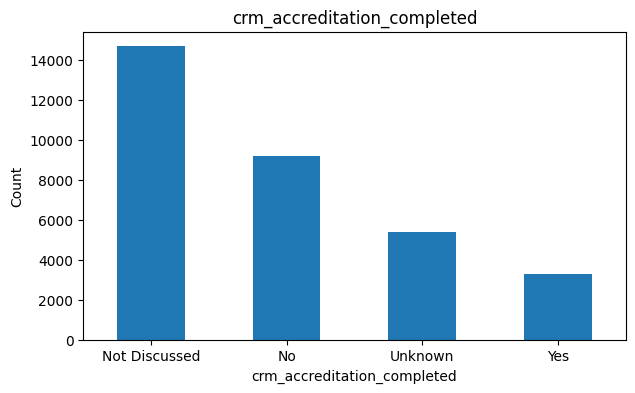


Top values in crm_timely_completion:
crm_timely_completion
Not Discussed    23566
Unknown           5362
No                3092
Yes                469
Name: count, dtype: int64


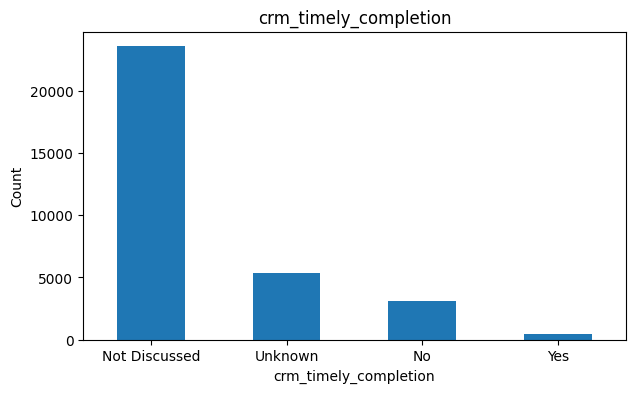


Top values in crm_progress_towards_accreditation:
crm_progress_towards_accreditation
Not Discussed    18364
Yes               7996
Unknown           5362
No                 767
Name: count, dtype: int64


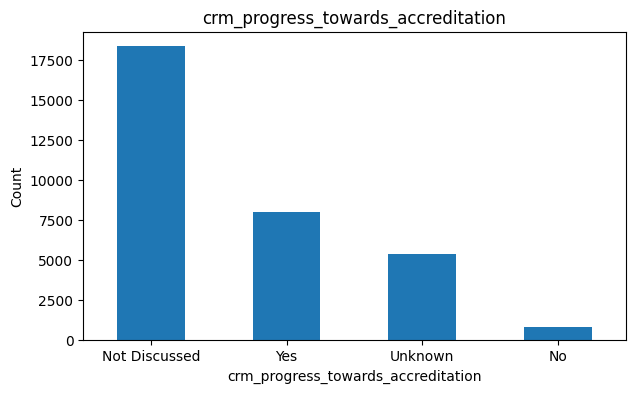


Top values in crm_delays_in_accreditation:
crm_delays_in_accreditation
No               21028
Unknown           5362
Yes               5250
Not Discussed      849
Name: count, dtype: int64


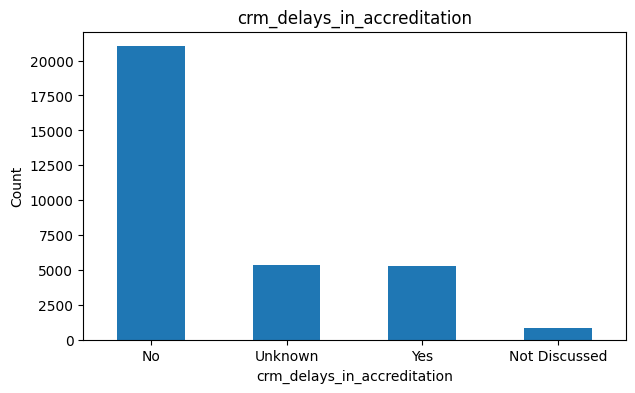


Top values in crm_contractor_suggested_leave:
crm_contractor_suggested_leave
No               17952
Not Discussed     6464
Unknown           5362
Yes               2711
Name: count, dtype: int64


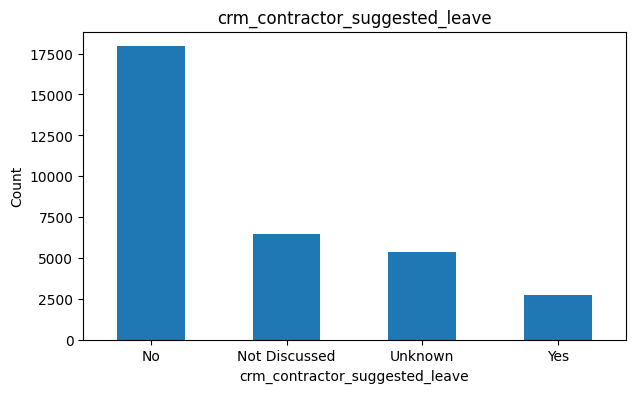


Top values in crm_contractor_engagement:
crm_contractor_engagement
Yes              15331
No               11790
Unknown           5364
Not Discussed        4
Name: count, dtype: int64


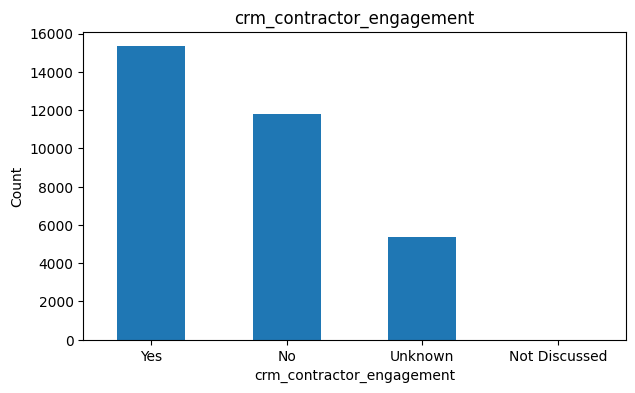


Top values in crm_contractor_sentiment:
crm_contractor_sentiment
Not Discussed    11772
Neutral           9796
Unknown           5362
Satisfied         4171
Dissatisfied      1388
Name: count, dtype: int64


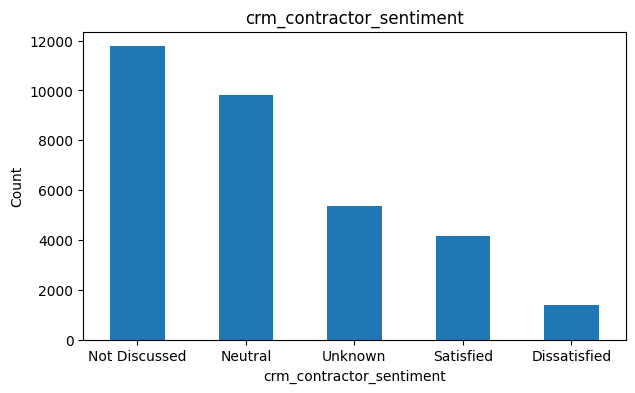


Top values in crm_contractor_sentiment_score:
crm_contractor_sentiment_score
Unknown         17145
Neutral          9792
Satisfied        4171
Dissatisfied     1381
Name: count, dtype: int64


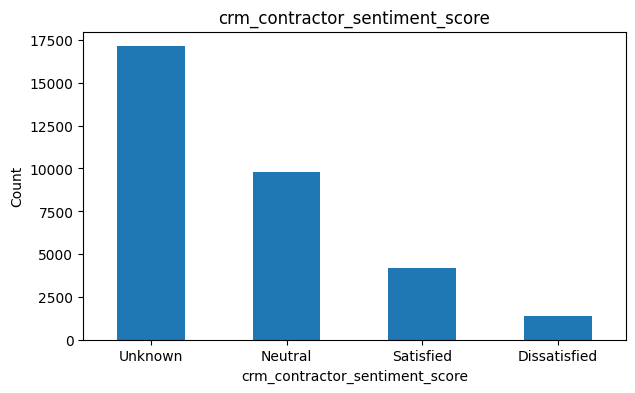


Top values in crm_dts_or_ssip_mentioned:
crm_dts_or_ssip_mentioned
No               21881
Unknown           5362
Yes               5245
Not Discussed        1
Name: count, dtype: int64


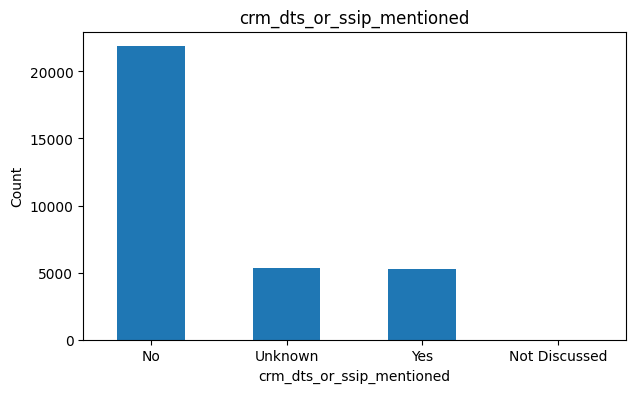


Top values in crm_customer_payment_intention:
crm_customer_payment_intention
Not Discussed    19947
Yes               5474
Unknown           5362
No                1706
Name: count, dtype: int64


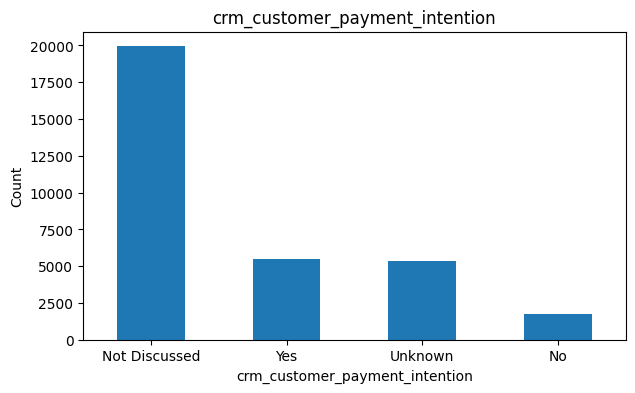


Top values in crm_competitors_mentioned:
crm_competitors_mentioned
No               17689
Not Discussed    11073
Unknown           3219
Yes                508
Name: count, dtype: int64


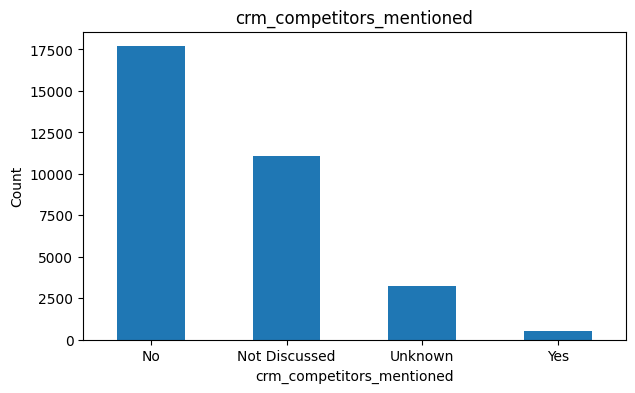


Top values in crm_membership_level:
crm_membership_level
Not Discussed       13798
In progress          8372
Accredited           6876
Unknown              3219
Members only          187
Not Accredited         15
Standard               13
Express                 2
Group Membership        1
Assisted Band C1        1
Name: count, dtype: int64


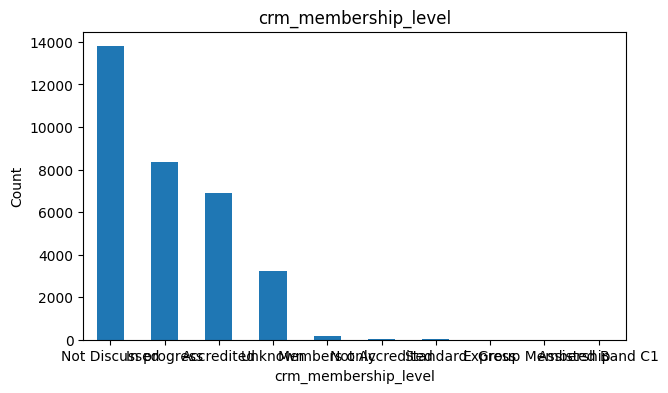


Top values in crm_platform_issues_raised:
crm_platform_issues_raised
No               18012
Not Discussed    10016
Unknown           3219
Yes               1242
Name: count, dtype: int64


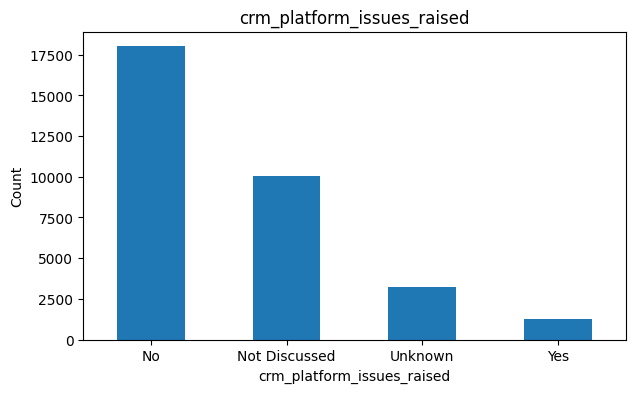


Top values in crm_agent_chased_contractor:
crm_agent_chased_contractor
Yes              14619
No               14301
Unknown           3219
Not Discussed      350
Name: count, dtype: int64


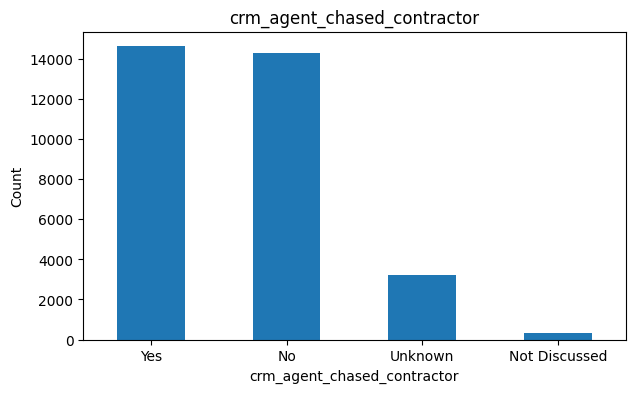


Top values in crm_agent_chase_count:
crm_agent_chase_count
Low        25257
Medium      3938
Unknown     3251
High          43
Name: count, dtype: int64


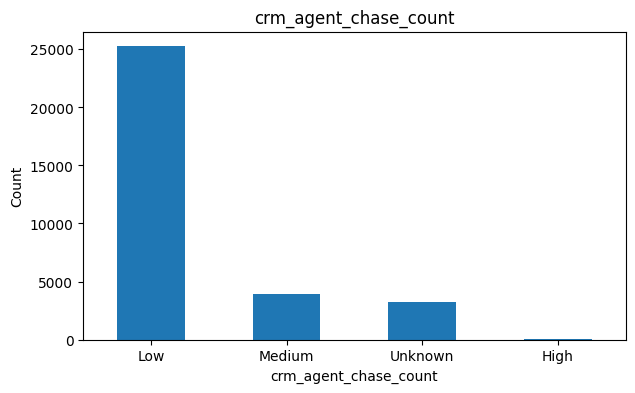


Top values in crm_accreditation_issues:
crm_accreditation_issues
Not Discussed    20889
Yes               4267
No                4114
Unknown           3219
Name: count, dtype: int64


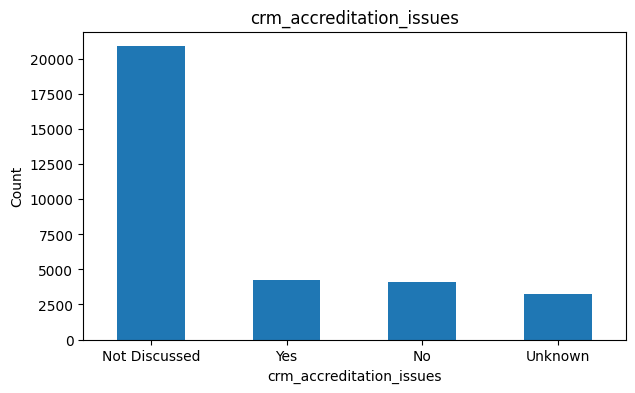


Top values in crm_membership_overdue:
crm_membership_overdue
Not Discussed    16324
No                8468
Yes               4468
Unknown           3229
Name: count, dtype: int64


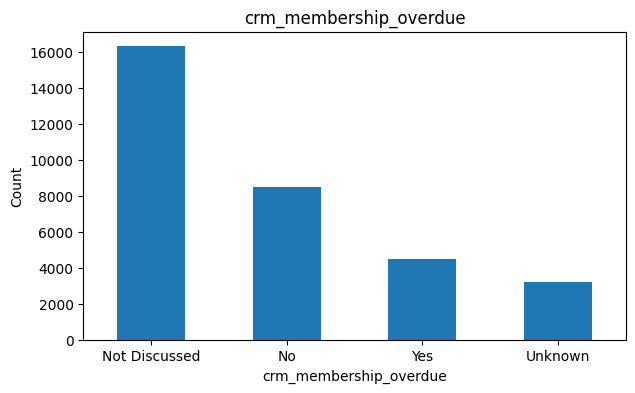


Top values in crm_auto_renewal_status:
crm_auto_renewal_status
No               25914
Unknown           5384
Yes               1187
Not Discussed        4
Name: count, dtype: int64


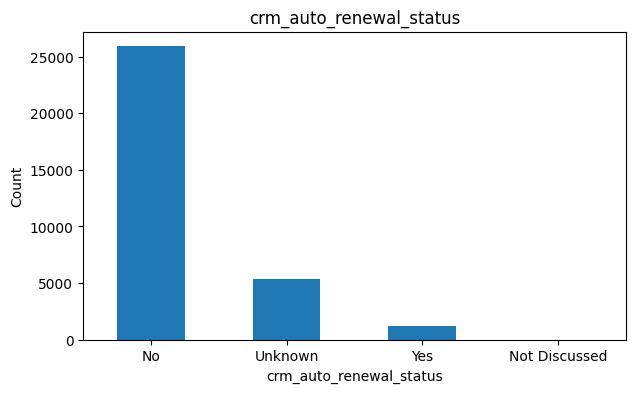


Top values in crm_dissatisified_with_renewal_price:
crm_dissatisified_with_renewal_price
Not Discussed    21510
No                6235
Unknown           3219
Yes               1525
Name: count, dtype: int64


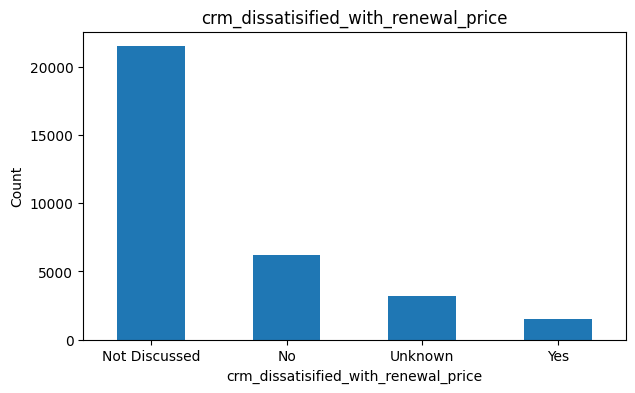


Top values in crm_customer_complained:
crm_customer_complained
No                27294
Unknown            3370
Yes                1803
Not Discussed        13
Not Applicable        9
Name: count, dtype: int64


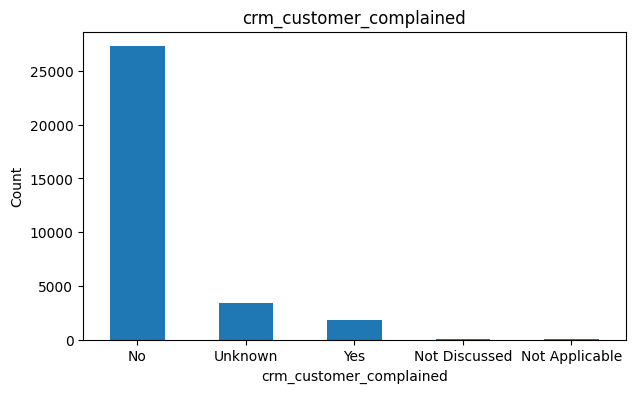


Top values in crm_refund_mentioned:
crm_refund_mentioned
No                                                                                         28913
Unknown                                                                                     3370
Yes                                                                                          183
Not Discussed                                                                                 21
"" with all questions on part one greyed out and part two already showing as complete."        1
Not Applicable                                                                                 1
Name: count, dtype: int64


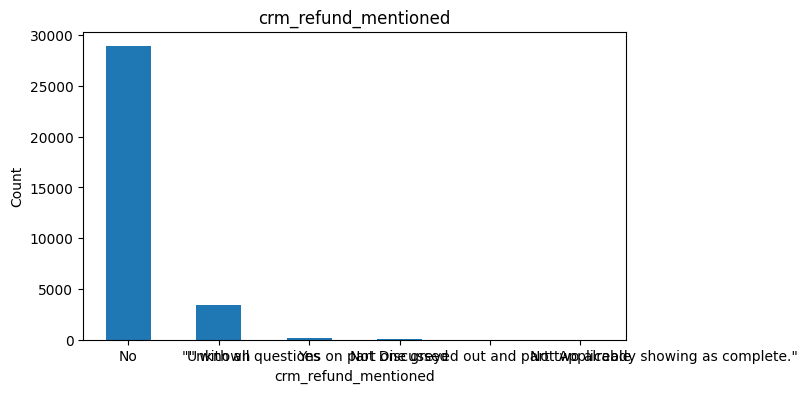


Top values in crm_negative_customer_experience:
crm_negative_customer_experience
No               16178
Not Discussed     9097
Yes               3844
Unknown           3370
Name: count, dtype: int64


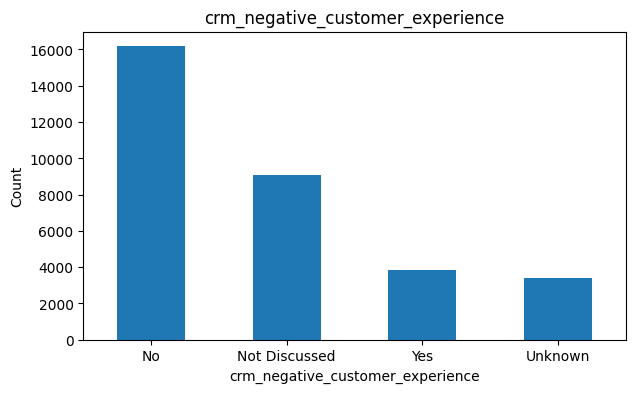


Top values in crm_dissatisfaction_with_support:
crm_dissatisfaction_with_support
No                                                                                                 15067
Not Discussed                                                                                      12135
Unknown                                                                                             3370
Yes                                                                                                 1916
The contractor experienced difficulties accessing the QA system, which hindered their progress.        1
Name: count, dtype: int64


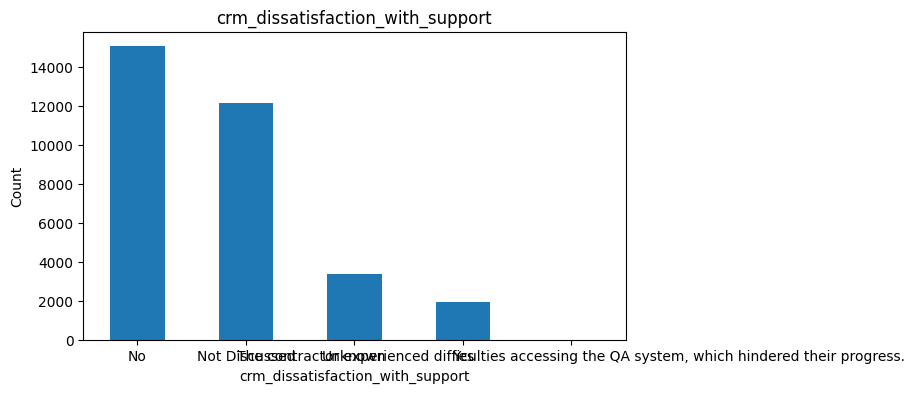


Top values in crm_financial_hardship_mentioned:
crm_financial_hardship_mentioned
Not Discussed    21552
No                6349
Unknown           3370
Yes               1206
Yes                 12
Name: count, dtype: int64


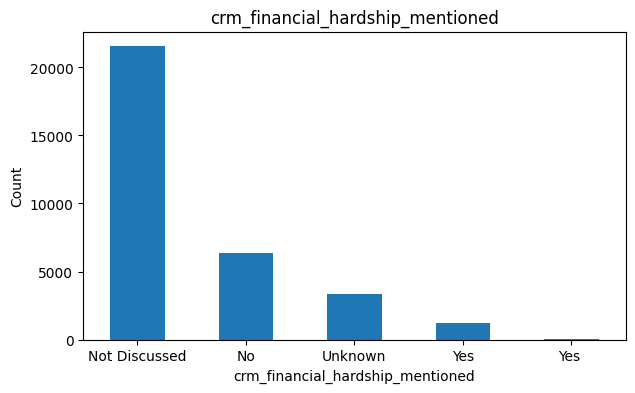


Top values in sentiment_category:
sentiment_category
Not Discussed    11772
Neutral           9792
Unknown           5373
Satisfied         4171
Dissatisfied      1381
Name: count, dtype: int64


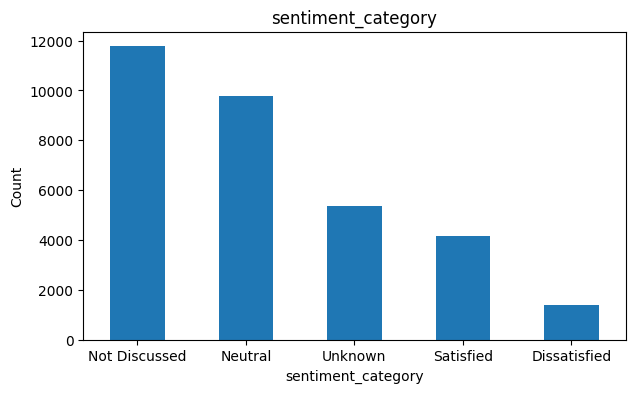

In [ ]:
for col in cat_cols:
    print(f"\nTop values in {col}:")
    print(emails[col].value_counts().head(10))
    
    plt.figure(figsize=(7,4))
    emails[col].value_counts().head(10).plot(kind='bar')
    plt.title(f'{col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()